In [28]:
import pandas as pd

In [29]:
df = pd.read_csv("healthcare_noshows.csv")
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,29-04-2016,29-04-2016,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,5.589980e+14,5642503,M,29-04-2016,29-04-2016,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4.262960e+12,5642549,F,29-04-2016,29-04-2016,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,8.679510e+11,5642828,F,29-04-2016,29-04-2016,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8.841190e+12,5642494,F,29-04-2016,29-04-2016,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106982,2.572130e+12,5651768,F,03-05-2016,07-06-2016,56,MARIA ORTIZ,False,False,False,False,False,True,True,35
106983,3.596270e+12,5650093,F,03-05-2016,07-06-2016,51,MARIA ORTIZ,False,False,False,False,False,True,True,35
106984,1.557660e+13,5630692,F,27-04-2016,07-06-2016,21,MARIA ORTIZ,False,False,False,False,False,True,True,41
106985,9.213490e+13,5630323,F,27-04-2016,07-06-2016,38,MARIA ORTIZ,False,False,False,False,False,True,True,41


In [30]:
df['No_show'] = df['Showed_up'].map({True:0, False:1})

In [31]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff,No_show
0,2.987250e+13,5642903,F,29-04-2016,29-04-2016,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0,0
1,5.589980e+14,5642503,M,29-04-2016,29-04-2016,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0,0
2,4.262960e+12,5642549,F,29-04-2016,29-04-2016,62,MATA DA PRAIA,False,False,False,False,False,False,True,0,0
3,8.679510e+11,5642828,F,29-04-2016,29-04-2016,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0,0
4,8.841190e+12,5642494,F,29-04-2016,29-04-2016,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0,0


In [32]:
df.tail()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff,No_show
106982,2.572130e+12,5651768,F,03-05-2016,07-06-2016,56,MARIA ORTIZ,False,False,False,False,False,True,True,35,0
106983,3.596270e+12,5650093,F,03-05-2016,07-06-2016,51,MARIA ORTIZ,False,False,False,False,False,True,True,35,0
106984,1.557660e+13,5630692,F,27-04-2016,07-06-2016,21,MARIA ORTIZ,False,False,False,False,False,True,True,41,0
106985,9.213490e+13,5630323,F,27-04-2016,07-06-2016,38,MARIA ORTIZ,False,False,False,False,False,True,True,41,0
106986,3.775120e+14,5629448,F,27-04-2016,07-06-2016,54,MARIA ORTIZ,False,False,False,False,False,True,True,41,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106987 entries, 0 to 106986
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       106987 non-null  float64
 1   AppointmentID   106987 non-null  int64  
 2   Gender          106987 non-null  object 
 3   ScheduledDay    106987 non-null  object 
 4   AppointmentDay  106987 non-null  object 
 5   Age             106987 non-null  int64  
 6   Neighbourhood   106987 non-null  object 
 7   Scholarship     106987 non-null  bool   
 8   Hipertension    106987 non-null  bool   
 9   Diabetes        106987 non-null  bool   
 10  Alcoholism      106987 non-null  bool   
 11  Handcap         106987 non-null  bool   
 12  SMS_received    106987 non-null  bool   
 13  Showed_up       106987 non-null  bool   
 14  Date.diff       106987 non-null  int64  
 15  No_show         106987 non-null  int64  
dtypes: bool(7), float64(1), int64(4), object(4)
memory usage

In [34]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], format='%d-%m-%Y')
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], format='%d-%m-%Y')

In [35]:
df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

In [36]:
df = df[df['WaitingDays'] >= 0]
df = df[df['Age'] >= 0]

In [37]:
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff,No_show,WaitingDays
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0,0,0
1,5.589980e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0,0,0
2,4.262960e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0,0,0
3,8.679510e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0,0,0
4,8.841190e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106982,2.572130e+12,5651768,F,2016-05-03,2016-06-07,56,MARIA ORTIZ,False,False,False,False,False,True,True,35,0,35
106983,3.596270e+12,5650093,F,2016-05-03,2016-06-07,51,MARIA ORTIZ,False,False,False,False,False,True,True,35,0,35
106984,1.557660e+13,5630692,F,2016-04-27,2016-06-07,21,MARIA ORTIZ,False,False,False,False,False,True,True,41,0,41
106985,9.213490e+13,5630323,F,2016-04-27,2016-06-07,38,MARIA ORTIZ,False,False,False,False,False,True,True,41,0,41


### Feature engineering

In [38]:
df['Weekday'] = df['AppointmentDay'].dt.day_name()

In [39]:
df['AgeGroup'] = pd.cut(df['Age'],
                       bins=[0,18,35,60,100],
                       labels=['Child','Young','Adult','Senior'])

In [40]:
df['SMS_received'] = df['SMS_received'].astype(int)

### EDA

In [41]:
df['No_show'].value_counts(normalize=True)

No_show
0    0.797396
1    0.202604
Name: proportion, dtype: float64

<Axes: xlabel='SMS_received', ylabel='count'>

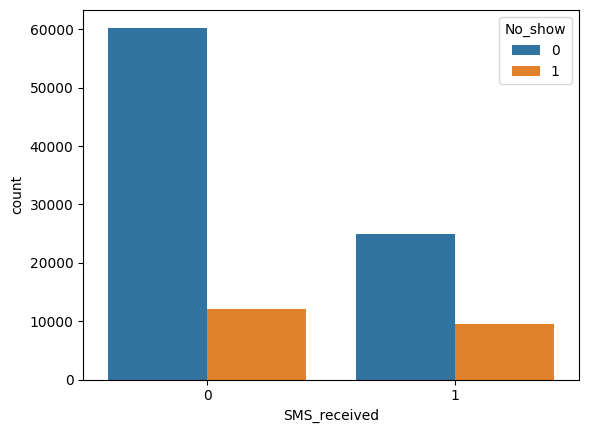

In [42]:
import seaborn as sns
sns.countplot(x='SMS_received', hue='No_show', data=df)

<Axes: xlabel='No_show', ylabel='Age'>

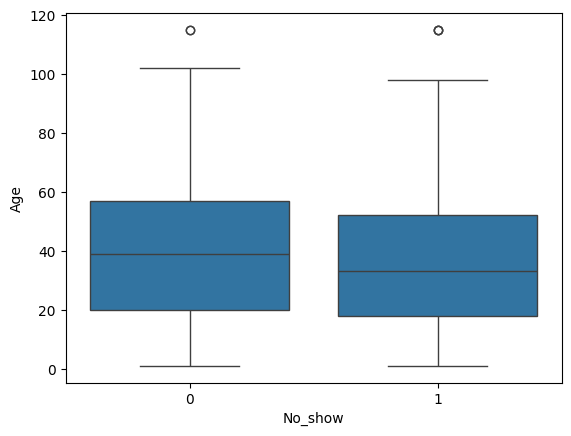

In [43]:
sns.boxplot(x='No_show', y='Age', data=df)

<Axes: xlabel='Weekday', ylabel='count'>

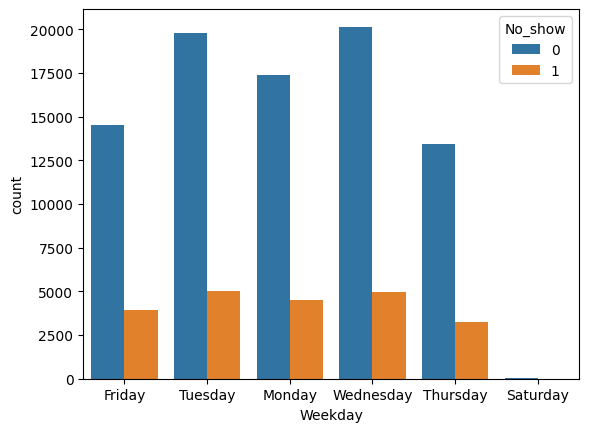

In [44]:
sns.countplot(x='Weekday', hue='No_show', data=df)

<Axes: xlabel='WaitingDays', ylabel='Count'>

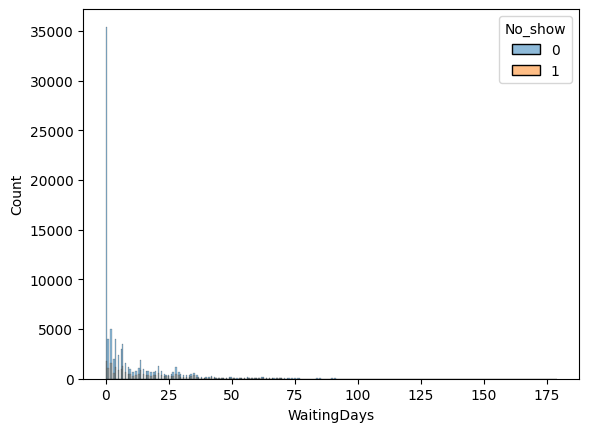

In [45]:
sns.histplot(data=df, x='WaitingDays', hue='No_show')

### Data Model

In [46]:
df_model = df.drop(['PatientId','AppointmentID','Showed_up','ScheduledDay','AppointmentDay'], axis=1)

In [47]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [48]:
from sklearn.model_selection import train_test_split

X = df_model.drop('No_show', axis=1)
y = df_model['No_show']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [49]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7974015048838622
Confusion Matrix:
 [[16994    72]
 [ 4263    68]]


In [51]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

WaitingDays                    0.752672
Age                            0.119666
Date.diff                      0.059049
SMS_received                   0.026191
Neighbourhood_GURIGICA         0.008990
Gender_M                       0.006576
Weekday_Tuesday                0.004996
Weekday_Monday                 0.003624
Neighbourhood_SANTOS DUMONT    0.003503
Hipertension                   0.003408
dtype: float64